# Imports

In [1]:
import os
import sys

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [6]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

### Functions

### Load data

In [7]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}
data = AS209

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

geom = Geometry(inc, pa, dra, ddec)

In [8]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 772
Rmax = 3.5999999999999996


In [9]:
cellsize = 2*Rmax / N
cellsize

0.00932642487046632

In [10]:
#N = 1000

In [11]:
cellsize = 2*Rmax/N
cellsize 

0.00932642487046632

#### UVcoverage

In [50]:
fig = plt.figure(figsize=(4, 4))

ax = fig.add_axes([0.1, 0.1, 0.75, 0.75]) 

log_abs_Vis = np.log(np.abs(Vis))
v_min_color = -10
v_max_color = -2
zoom_factor = 1

scatter = ax.scatter(-u, 
                     -v, 
                     c=log_abs_Vis,
                     marker=',',
                     alpha=0.5,
                     cmap='magma',
                     vmin=v_min_color,
                     vmax=v_max_color)

ax.set_xlim(1e7 / zoom_factor, -1e7 / zoom_factor)
ax.set_ylim(-1e7 / zoom_factor, 1e7/ zoom_factor) 


ax.set_xlabel(r'u [$\lambda$]', size=14)
ax.set_ylabel(r'v [$\lambda$]', size=14)
ax.tick_params(axis='both',    # Puede ser 'x', 'y' o 'both'
               which='major',  # Puede ser 'major', 'minor' o 'both'
               labelsize=12,   # Tamaño de la FUENTE (los números)
               length=5,      # Longitud de la MARCA (la línea)
               width=2)

ax.set_aspect('equal', adjustable='box') 

cb_ax = fig.add_axes([0.87, 0.1, 0.03, 0.75]) 

cbar = plt.colorbar(scatter, cax=cb_ax)
cbar.set_label(r'log$\|V\|$ [Jy]', size=14)


plt.show()

KeyboardInterrupt: 

#### Power spectrum

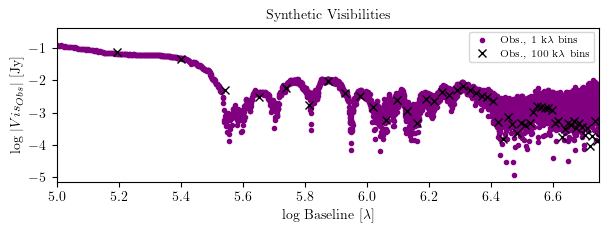

In [10]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, marker=ms[0], ls='None', c ='purple', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Synthetic Visibilities", size = 10)
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

Power spectrum fit: m =  -1 , c =  1412.537544622754


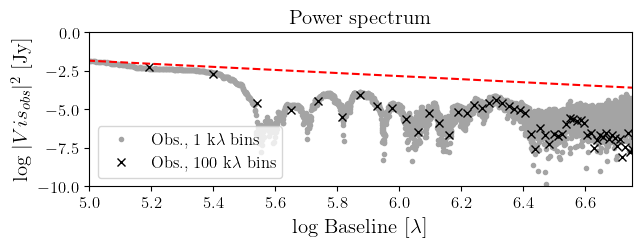

In [11]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

m0 = -1
p0 = -1.85
logc0 = p0 - 5*m0
c0 = 10**logc0
print("Power spectrum fit: m = ", m0, ", c = ", c0)
lgy = linear_power_spectrum(lgx, m0, c0)
plt.plot(lgx, lgy, c='red', ls='--')

plt.xlabel(r'log Baseline [$\lambda$]', size = 15)
plt.ylabel(r'log $|Vis_{obs}|^{2}$ [Jy]', size = 15)
plt.legend(loc = 'best', fontsize = 12)
plt.title("Power spectrum", size = 15)
plt.tick_params(axis='both', which='both', labelsize=12)
plt.ylim(-10, 0)
plt.xlim(5, 6.75)
plt.show()

In [12]:
initial = {'m': m0, 'c': c0, 'l': 10**4}

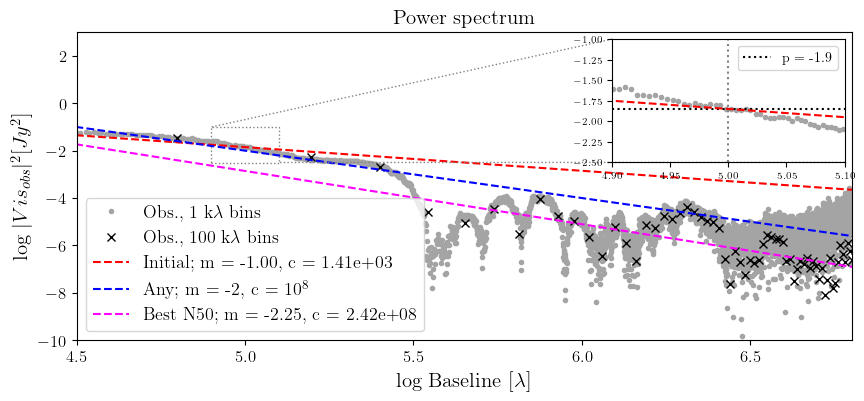

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
ax.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


lgy = linear_power_spectrum(lgx, m0, c0)
lgy1 = linear_power_spectrum(lgx, -2, 10**8)
best_N50 = {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266} # 18m12.2s
lgy2 = linear_power_spectrum(lgx, best_N50['m'], best_N50['c'])
ax.plot(lgx, lgy, c='red', ls='--', label='Initial; m = {:.2f}'.format(m0) +', c = {:.2e}'.format(c0))
ax.plot(lgx, lgy1, c='blue', ls='--', label='Any; m = -2, c = $10^{8}$')
ax.plot(lgx, lgy2, c='magenta', ls='--', label='Best N50; m = {:.2f}'.format(best_N50['m']) +', c = {:.2e}'.format(best_N50['c']))


ax.set_xlabel(r'log Baseline [$\lambda$]', size=15)
ax.set_ylabel(r'log $|Vis_{obs}|^{2} [Jy^2]$', size=15)
ax.legend(loc='lower left', fontsize=13)
ax.tick_params(axis='both', which='both', labelsize=12)
ax.set_title("Power spectrum", size=15)
ax.set_ylim(-10, 3) 
ax.set_xlim(4.5, 6.8)

axins = inset_axes(ax, width="30%", height="40%", loc=1)

axins.plot(logx, logy, c=cs[0], marker=ms[0], ls='None')
axins.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None')
axins.axhline(p0, c='black', ls=':', label='p = {:.1f}'.format(p0))
axins.axvline(5, c='gray', ls=':')
axins.plot(lgx, lgy, c='red', ls='--')
axins.legend(fontsize=10)

axins.set_xlim(4.9, 5.1)
axins.set_ylim(-2.5, -1)

axins.tick_params(labelsize=7)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", ls=':')

plt.show()

In [48]:
print(p, m, c)

-1.85 -1 1412.537544622754


### Dirty image

In [10]:
frank2d0 = Frank2D(N, Rmax)

In [11]:
frank2d0.dx

0.00932642487046632

In [12]:

print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11458.93439803405, q_max data: 8857254.46918468


In [13]:
Un = frank2d0.FT.uv_points[0]
Vn = frank2d0.FT.uv_points[1]

Qn = np.sort(np.hypot(Un, Vn))

q_min_f2d = Qn[1]
q_max_f2d = Qn[-1]
print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")

-> q_min frank2d: 28647.889756541164, q_max frank2d: 15638494.411648935


In [14]:
frank2d0.process_vis(uvtable, hermitian = True)

===>  Setting gridded data...


In [15]:
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
vis = frank2d0.gridded_data['vis']
weights = frank2d0.gridded_data['weights']

In [16]:
Plot_f2d0 = Plot(frank2d0, geom)

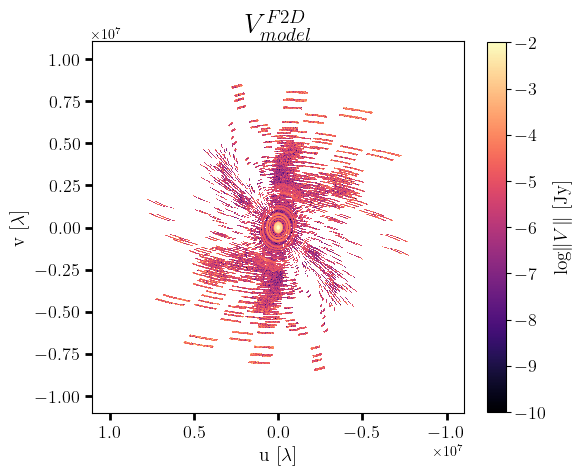

In [18]:
Plot_f2d0.visibility(kind = 'input')

In [42]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

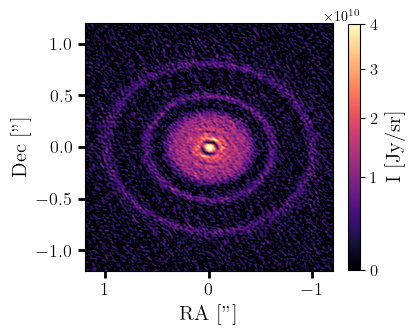

In [57]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 0.7, vmax=4e10, vmin = 0)
plt.figure(figsize=(4,4))
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma',
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Mock data', size =10)
plt.xlabel(r'RA ["]', size=15, weight='extra bold')
plt.ylabel('Dec ["]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=12)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)

### Frank2D

In [27]:
N

772

In [28]:
Rmax

3.5999999999999996

In [29]:
frank2d2 = Frank2D(N, Rmax)

In [30]:
frank2d2.dx

0.00932642487046632

In [31]:
frank2d2.process_vis(uvtable)

===>  Setting gridded data...


In [32]:
frank2d2.fit( rtol = 1e-10, kernel_params=initial)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1, 'c': 1412.537544622754, 'l': 10000}
===>  Creating sparse linear system...


        +  Kernel = 0.02  min |  1.31 seconds
        +  Building system = 0.02  min |  1.32 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 3/50000 [00:00<1:00:23, 13.80 iterations/s]


            +  BiCGStab = 0.00  min |  0.22 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 3,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.15  min |  8.86 seconds
--> times building full visibility model = 0.15  min |  8.88 seconds


In [55]:
#frank2d2.fit(data = uvtable, rtol = 1e-10)

In [33]:
Plot_ = Plot(frank2d2, geom)

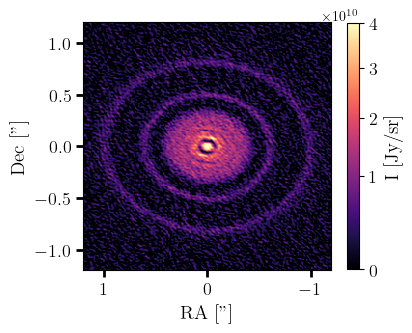

In [34]:
Plot_.intensity(vmax=4e10, gamma = 0.7, zoom = 3, title = '', fig_size = 4)

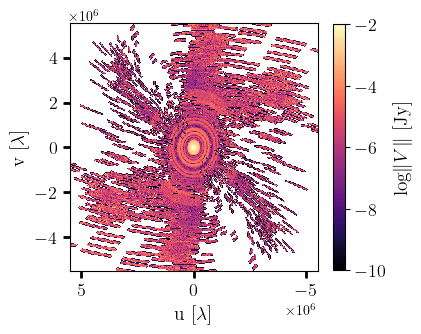

In [35]:
Plot_.visibility(fig_size=4, title='', zoom=2)

###  Best

In [59]:
p = -1.85 # before p = -2
m = -1 # before m = -2
initial_guess = {'p': p, 'm': m, 'logl': 4}

In [60]:
frank2d2.search_MAP(initial_guess= initial_guess, N = 50)

Using existing visibility data...
===>  Searching for MAP...
        + Initial guess:  {'p': -1.85, 'm': -1, 'logl': 4}
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 401.78 seconds
Setting the initial guess...
Optimizing the posterior...
 + Time to optimize the posterior: 685.51 seconds


In [61]:
frank2d2.MAP

{'m': -2.2478959006345174, 'c': 241569843.02864328, 'l': 37853.89645392957}

### Frank2D with best values

In [24]:
best_N50 = {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266} # 18m12.2s
maps = [best_N50]
Qmaxs = [1012855.85567674, 1417998.19794744, 1215427.02681209, 1620569.36908279, 2025711.71135349]

In [25]:
frank2d3 = Frank2D(N, Rmax)

In [26]:
N

772

In [27]:
frank2d3.process_vis(uvtable)

===>  Setting gridded data...


In [28]:
frank2d3.fit(kernel_params = best_N50, rtol = 1e-10) # 1m14.7s

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266}
===>  Creating sparse linear system...


        +  Kernel = 0.05  min |  2.76 seconds
        +  Building system = 0.05  min |  2.83 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 170/50000 [00:14<1:09:32, 11.94 iterations/s]


            +  BiCGStab = 0.24  min |  14.27 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 170,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.16  min |  9.58 seconds
--> times building full visibility model = 0.16  min |  9.62 seconds


In [68]:
#frank2d3.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10) # 1m7s

In [73]:
Plot_3 = Plot(frank2d3, geom)

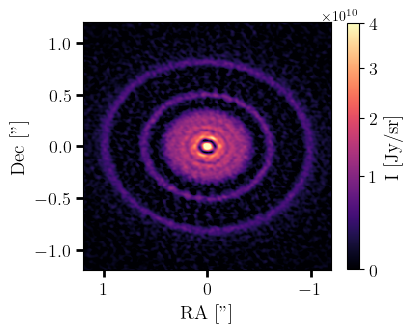

In [74]:
Plot_3.intensity(vmax=4e10, gamma = 0.7, zoom = 3, title = r'', fig_size= 4)

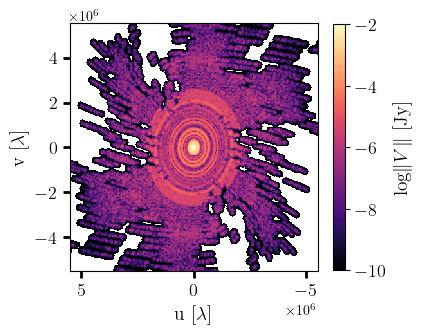

In [75]:
Plot_3.visibility(fig_size=4, zoom = 2,  title = r'')

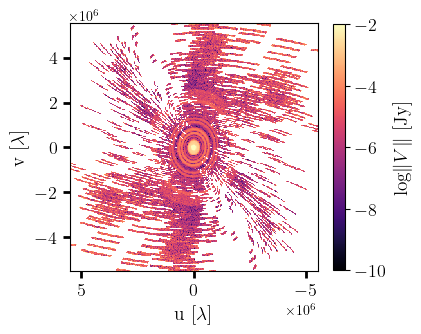

In [72]:
Plot_3.visibility(fig_size=4, zoom = 2,  title = r'', kind='input')

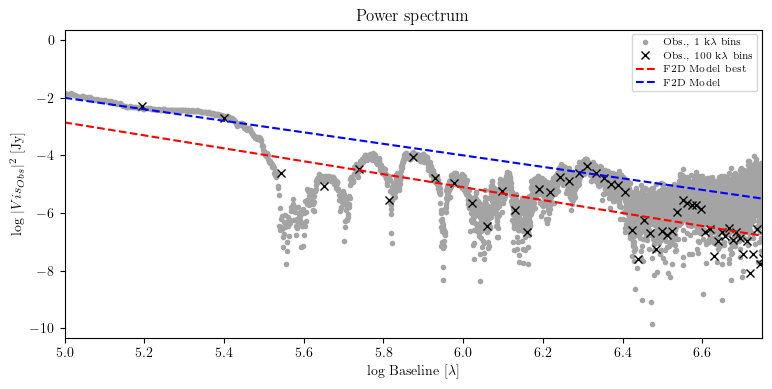

In [45]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

lgy_best = linear_power_spectrum(lgx, best_N50['m'], best_N50['c'])
lgy_ = linear_power_spectrum(lgx,-2,1e8)

plt.plot(lgx, lgy_best, 'r--', label='F2D Model best')
plt.plot(lgx, lgy_, 'b--', label='F2D Model')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

## All N_opts

In [17]:
maps = []
Qmaxs = []

import pickle
dir = "../../data/exp/N_opt/"
Nopts =[50, 60, 70, 80, 100]
#import objects
for i in Nopts:
    file_name = dir + "AS209_optGPU_Nopt" + str(i) + ".pkl"
    with open(file_name, 'rb') as file:
        frank_obj = pickle.load(file)
        frank_objs.append(frank_obj)
        maps.append(frank_obj.MAP)
        Qmaxs.append(frank_obj.FT.Qmax.get())

In [19]:
maps

[{'m': -2.2478884369552747, 'c': 241549975.19621062, 'l': 37854.08175500866},
 {'m': -1.7999547096142303, 'c': 950825.4061845761, 'l': 38844.463045304794},
 {'m': -1.5813994077657778, 'c': 63116.673789396744, 'l': 38055.1640187868},
 {'m': -1.3385403201640347, 'c': 2973.1064537333973, 'l': 38691.25638685321},
 {'m': -1.0274069740322451, 'c': 55.22595775195344, 'l': 35674.195061247774}]

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2478884369552747, 'c': 241549975.19621062, 'l': 37854.08175500866}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  2.88 seconds
        +  Building system = 0.05  min |  2.96 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 402/50000 [00:35<1:13:48, 11.20 iterations/s]


            +  BiCGStab = 0.60  min |  35.90 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 402,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.17  min |  10.40 seconds
--> times building full visibility model = 0.17  min |  10.45 seconds


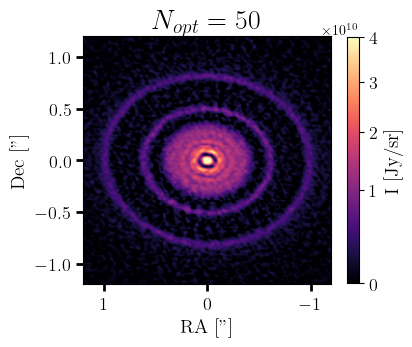

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.7999547096142303, 'c': 950825.4061845761, 'l': 38844.463045304794}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  3.04 seconds
        +  Building system = 0.05  min |  3.12 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 158/50000 [00:14<1:15:20, 11.03 iterations/s]


            +  BiCGStab = 0.24  min |  14.33 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 158,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.17  min |  10.27 seconds
--> times building full visibility model = 0.17  min |  10.31 seconds


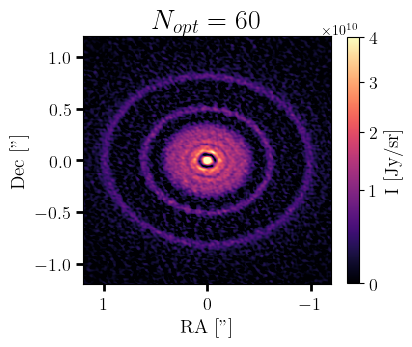

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.5813994077657778, 'c': 63116.673789396744, 'l': 38055.1640187868}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  2.84 seconds
        +  Building system = 0.05  min |  2.91 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 143/50000 [00:12<1:12:36, 11.44 iterations/s]


            +  BiCGStab = 0.21  min |  12.50 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 143,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.17  min |  10.36 seconds
--> times building full visibility model = 0.17  min |  10.40 seconds


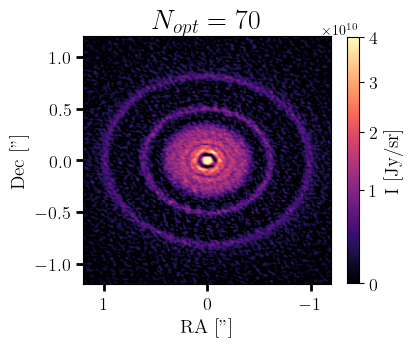

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.3385403201640347, 'c': 2973.1064537333973, 'l': 38691.25638685321}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  3.02 seconds
        +  Building system = 0.05  min |  3.10 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 159/50000 [00:14<1:15:11, 11.05 iterations/s]


            +  BiCGStab = 0.24  min |  14.40 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 159,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.18  min |  10.56 seconds
--> times building full visibility model = 0.18  min |  10.60 seconds


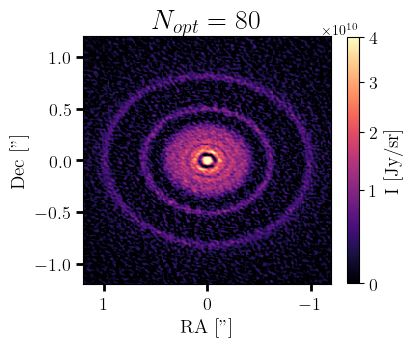

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.0274069740322451, 'c': 55.22595775195344, 'l': 35674.195061247774}
===>  Creating sparse linear system...
        +  Kernel = 0.04  min |  2.68 seconds
        +  Building system = 0.05  min |  2.74 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 120/50000 [00:09<1:08:47, 12.09 iterations/s]


            +  BiCGStab = 0.17  min |  9.93 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 120,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.17  min |  10.19 seconds
--> times building full visibility model = 0.17  min |  10.22 seconds


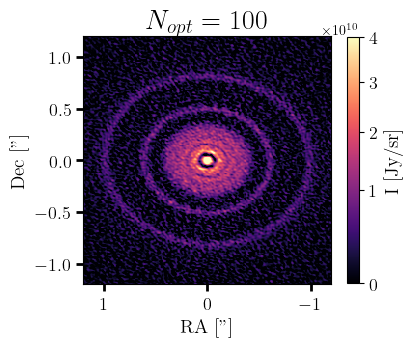

In [18]:
for index in range(len(Nopts)):
        frank_obj = Frank2D(N, Rmax)
        frank_obj.process_vis(uvtable)
        frank_obj.fit(kernel_params = maps[index], rtol = 1e-10)
        Plot_ = Plot(frank_obj, geom)
        Plot_.intensity(vmax=4e10, gamma = 0.7, zoom = 3, title = r'$N_{opt}$ = ' + str(Nopts[index]), fig_size= 4)

In [20]:
from frank.utilities import UVDataBinner       

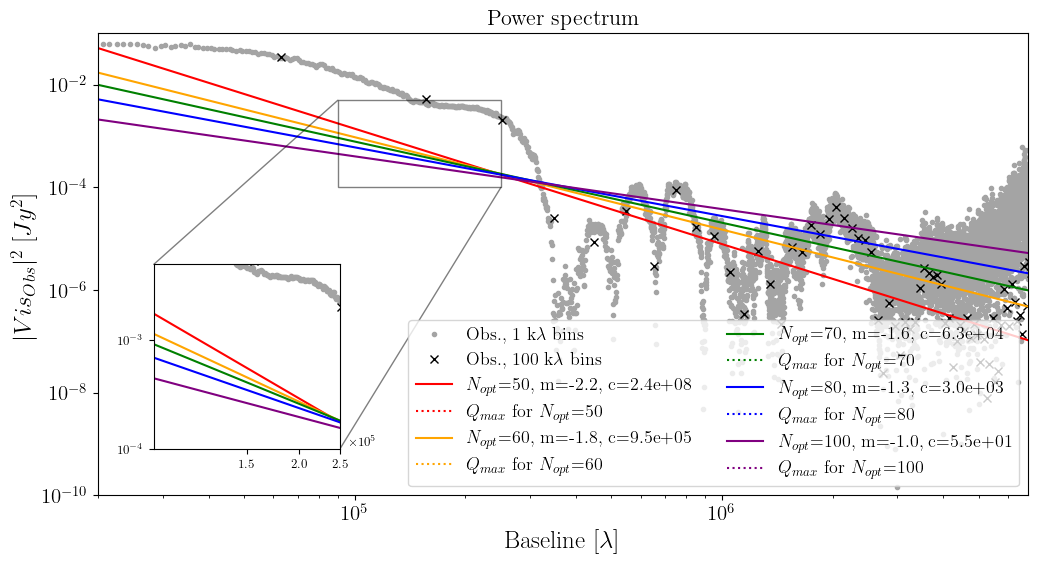

In [22]:
zoom_xlim = [9e4, 9.1e4]   # Límites en X (Baseline)
zoom_ylim = [1e-4, 0.5e-2] # Límites en Y (Visibilidad)

# Define dónde quieres que aparezca el recuadro del zoom dentro del gráfico
# Formato: [x, y, ancho, alto] en coordenadas relativas (0 a 1)
# Ejemplo: [0.05, 0.05, 0.4, 0.4] es abajo a la izquierda
inset_position = [0.06, 0.1, 0.2, 0.4] 

# --- B. CONFIGURACIÓN DE DATOS (Tu código original) ---
N_opts = [50, 60, 70, 80, 100]
colors = ['r', 'orange', 'g', 'b', 'purple']

current_maps = maps[:len(N_opts)] 
current_Qmaxs = Qmaxs[:len(N_opts)]

bin_widths = [1e3, 1e5]
obs_styles = [
    {'color': '#a4a4a4', 'marker': '.', 'label_suffix': ''},
    {'color': 'k',       'marker': 'x', 'label_suffix': ''}
]

def power_spectrum(x, m, c):
    return c * x**(m)

baselines = np.hypot(u, v)
x_model = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)


fig, ax = plt.subplots(figsize=(12, 6))

axins = ax.inset_axes(inset_position)

for width, style in zip(bin_widths, obs_styles):
    binned = UVDataBinner(baselines, Vis, Weights, width)
    
    # 1. Ploteamos en el eje PRINCIPAL (ax)
    ax.plot(binned.uv, np.abs(binned.V)**2, 
            c=style['color'], marker=style['marker'], ls='None', 
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(width/1e3))
    
    # 2. Ploteamos lo mismo en el eje ZOOM (axins)
    axins.plot(binned.uv, np.abs(binned.V)**2, 
               c=style['color'], marker=style['marker'], ls='None')

# --- BLOQUE 2: Plotear Modelos y Qmax ---
for N, params, Qmax_val, color in zip(N_opts, current_maps, current_Qmaxs, colors):
    if callable(Qmax_val): Qmax = Qmax_val()
    else: Qmax = Qmax_val

    y_model = power_spectrum(x_model, params['m'], params['c'])
    label_text = f"$N_{{opt}}$={N}, m={params['m']:.1f}, c={params['c']:.1e}"
    
    # 1. Eje PRINCIPAL
    ax.plot(x_model, y_model, c=color, label=label_text)
    qmax_label = f"$Q_{{max}}$ for $N_{{opt}}$={N}"
    ax.axvline(Qmax, color=color, ls=':', label=qmax_label)
    
    # 2. Eje ZOOM
    axins.plot(x_model, y_model, c=color)
    axins.axvline(Qmax, color=color, ls=':')

# --- D. CONFIGURACIÓN FINAL ---

# Configuración del Eje Principal
ax.set_xlabel(r'Baseline [$\lambda$]', size=18)
ax.set_ylabel(r'$|Vis_{Obs}|^{2}$ [$Jy^2$]', size=18)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylim(1e-10, 1e-1)
ax.set_xlim(2e4, 6.8e6)
ax.set_title("Power spectrum", size=16)
ax.legend(loc='lower right', fontsize=13, ncol=2)

# Configuración del Eje Zoom (axins)
axins.set_xlim(zoom_xlim) # Aquí se aplican tus límites
axins.set_ylim(zoom_ylim) # Aquí se aplican tus límites
axins.set_xscale('log')
axins.set_yscale('log')
# 2. ELIMINAR LA MANCHA NEGRA (Minor Ticks)
# Esto borra las rayitas pequeñas que se amontonan
axins.minorticks_off()

# 3. FORZAR TICKS MANUALES
# Le decimos: "Solo dibuja una línea en estos 3 puntos exactos"
mis_ticks = [1.5e5, 2.0e5, 2.5e5]
axins.set_xticks(mis_ticks)

# 4. FORZAR ETIQUETAS DE TEXTO (Strings)
# Le decimos: "No calcules nada, solo escribe este texto en esos puntos"
# Esto evita que ponga notación científica superpuesta
axins.set_xticklabels(["1.5", "2.0", "2.5"], fontsize=9)

# 5. Agregar manualmente la potencia (x10^5) en la esquina
# coordinates relativas (0 a 1) dentro del axins
axins.text(1.2, 0.01, r'$\times 10^5$', 
           transform=axins.transAxes, ha='right', va='bottom', fontsize=9)

# Configuración del eje Y (lo dejamos automático pero pequeño)
axins.tick_params(axis='y', labelsize=9)

ax.indicate_inset_zoom(axins, edgecolor="black")

plt.show()